In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)
n=2000
applicant_id = np.arange(100001, 100001 + n)
print(applicant_id[:10])
gender = np.random.choice(
    ["Male", "Female"],
    size=n
)
print(gender[:10])
age = np.random.randint(
    21,
    61,
    size=n
)
print(age[:10])
employment_status = np.random.choice(
    ["Employed", "Self-Employed", "Unemployed"],
    size=n,
    p=[0.60, 0.30, 0.10]
)
print(employment_status[:10])

[100001 100002 100003 100004 100005 100006 100007 100008 100009 100010]
['Male' 'Female' 'Male' 'Male' 'Male' 'Female' 'Male' 'Male' 'Male'
 'Female']
[32 36 44 39 28 51 41 37 43 57]
['Employed' 'Employed' 'Unemployed' 'Self-Employed' 'Employed' 'Employed'
 'Self-Employed' 'Self-Employed' 'Self-Employed' 'Employed']


In [3]:
income_base = (
    18000
    + (age - 21) * 1100
    + np.where(employment_status == "Self-Employed", 9000, 0)
    + np.where(employment_status == "Unemployed", -9000, 0)
)

monthly_income = (
    income_base + np.random.normal(0, 12000, n)
)

monthly_income = np.maximum(
    7000,
    monthly_income
).round(0)

print(monthly_income[:10])

[18169. 30000. 26537. 34601. 10770. 70972. 49128. 41909. 57011. 64005.]


In [4]:
credit_score = (
    520
    + (monthly_income - 15000) / 180
    + np.where(
        employment_status == "Employed",
        25,
        0
    )
    + np.where(
        employment_status == "Self-Employed",
        10,
        0
    )
    + np.random.normal(0, 55, n)
)

credit_score = np.clip(
    credit_score,
    300,
    850
).round(0)

print(credit_score[:10])

[569. 619. 582. 596. 551. 818. 726. 727. 850. 826.]


In [5]:
existing_loans = np.random.poisson(
    1.2,
    n
)

existing_loans = np.clip(
    existing_loans,
    0,
    6
)

print(existing_loans[:10])
loan_amount = (
    monthly_income *
    np.random.uniform(2.0, 7.0, n)
    + np.random.normal(0, 25000, n)
)

loan_amount = np.maximum(
    20000,
    loan_amount
).round(0)

print(loan_amount[:10])
loan_term = np.random.choice(
    [12, 24, 36, 48, 60],
    size=n,
    p=[0.10, 0.20, 0.35, 0.20, 0.15]
)

print(loan_term[:10])

[0 4 0 1 1 3 1 3 3 0]
[162004.  78884. 141011. 228748.  54137. 170504. 180642. 118238. 269813.
 197783.]
[36 24 60 24 60 48 48 48 36 48]


In [6]:
property_area = np.random.choice(
    ["Urban", "Semi-Urban", "Rural"],
    size=n,
    p=[0.45, 0.35, 0.20]
)
print(property_area[:10])

['Urban' 'Semi-Urban' 'Urban' 'Rural' 'Semi-Urban' 'Urban' 'Urban'
 'Semi-Urban' 'Urban' 'Rural']


In [8]:
income_score = np.clip(
    (monthly_income - 15000) / 60000,
    -1,
    1
)

credit_score_norm = (
    credit_score - 600
) / 100

loan_burden = (
    loan_amount /
    np.maximum(monthly_income, 1)
)

loan_burden_score = np.clip(
    (4.5 - loan_burden) / 3.0,
    -1.5,
    1.5
)
employment_score = np.select(
    [
        employment_status == "Employed",
        employment_status == "Self-Employed",
        employment_status == "Unemployed"
    ],
    [
        0.55,
        0.25,
        -1.25
    ],
    default=0
)
existing_loan_score = np.clip(
    (3 - existing_loans) / 3,
    -1,
    1
)

print(existing_loan_score[:10])

[ 1.         -0.33333333  1.          0.66666667  0.66666667  0.
  0.66666667  0.          0.          1.        ]


In [9]:
logit = (
    -0.25
    + 1.25 * income_score
    + 1.55 * credit_score_norm
    + 0.95 * loan_burden_score
    + employment_score
    + existing_loan_score
    + np.random.normal(0, 0.55, n)
)
approval_probability = (
    1 / (1 + np.exp(-logit))
)
loan_approved = np.random.binomial(
    1,
    approval_probability
)

In [10]:
df = pd.DataFrame({
    "ApplicantID": applicant_id,
    "Gender": gender,
    "Age": age,
    "MonthlyIncome": monthly_income,
    "LoanAmount": loan_amount,
    "CreditScore": credit_score,
    "EmploymentStatus": employment_status,
    "ExistingLoans": existing_loans,
    "LoanTerm": loan_term,
    "PropertyArea": property_area,
    "LoanApproved": loan_approved
})
df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,100001,Male,32,18169.0,162004.0,569.0,Employed,0,36,Urban,0
1,100002,Female,36,30000.0,78884.0,619.0,Employed,4,24,Semi-Urban,1
2,100003,Male,44,26537.0,141011.0,582.0,Unemployed,0,60,Urban,0
3,100004,Male,39,34601.0,228748.0,596.0,Self-Employed,1,24,Rural,0
4,100005,Male,28,10770.0,54137.0,551.0,Employed,1,60,Semi-Urban,0


In [15]:
# ==========================================
# STEP 8: DATA CLEANING AND VALIDATION
# ==========================================

# 1. Check dataset information
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

# 2. Check missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# 3. Handle missing numerical values
numeric_columns = [
    "Age",
    "MonthlyIncome",
    "LoanAmount",
    "CreditScore",
    "ExistingLoans",
    "LoanTerm"
]

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

# 4. Handle missing categorical values
categorical_columns = [
    "Gender",
    "EmploymentStatus",
    "PropertyArea"
]

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

# 5. Remove duplicate rows
df = df.drop_duplicates()

# 6. Validate age
df.loc[
    (df["Age"] < 18) | (df["Age"] > 100),
    "Age"
] = np.nan

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# 7. Validate credit score
df.loc[
    (df["CreditScore"] < 300) |
    (df["CreditScore"] > 850),
    "CreditScore"
] = np.nan

df["CreditScore"] = df["CreditScore"].fillna(
    df["CreditScore"].median()
)

# 8. Validate income
df.loc[
    df["MonthlyIncome"] < 0,
    "MonthlyIncome"
] = np.nan

df["MonthlyIncome"] = df["MonthlyIncome"].fillna(
    df["MonthlyIncome"].median()
)

# 9. Validate loan amount
df.loc[
    df["LoanAmount"] < 0,
    "LoanAmount"
] = np.nan

df["LoanAmount"] = df["LoanAmount"].fillna(
    df["LoanAmount"].median()
)

# 10. Final checks
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print(
    "\nDuplicate rows after cleaning:",
    df.duplicated().sum()
)

print("\nFinal dataset shape:")
print(df.shape)

# 11. Save cleaned dataset
df.to_csv(
    "loan_applications.csv",
    index=False
)

print("\nCleaned dataset saved successfully!")

Dataset shape: (2000, 11)

Data types:
ApplicantID           int64
Gender                  str
Age                   int32
MonthlyIncome       float64
LoanAmount          float64
CreditScore         float64
EmploymentStatus        str
ExistingLoans         int32
LoanTerm              int64
PropertyArea            str
LoanApproved          int32
dtype: object

Missing values before cleaning:
ApplicantID         0
Gender              0
Age                 0
MonthlyIncome       0
LoanAmount          0
CreditScore         0
EmploymentStatus    0
ExistingLoans       0
LoanTerm            0
PropertyArea        0
LoanApproved        0
dtype: int64

Missing values after cleaning:
ApplicantID         0
Gender              0
Age                 0
MonthlyIncome       0
LoanAmount          0
CreditScore         0
EmploymentStatus    0
ExistingLoans       0
LoanTerm            0
PropertyArea        0
LoanApproved        0
dtype: int64

Duplicate rows after cleaning: 0

Final dataset shape:
(2000, 1

In [12]:

print(df["LoanApproved"].value_counts())

(2000, 11)
   ApplicantID  Gender  Age  MonthlyIncome  LoanAmount  CreditScore  \
0       100001    Male   32        18169.0    162004.0        569.0   
1       100002  Female   36        30000.0     78884.0        619.0   
2       100003    Male   44        26537.0    141011.0        582.0   
3       100004    Male   39        34601.0    228748.0        596.0   
4       100005    Male   28        10770.0     54137.0        551.0   

  EmploymentStatus  ExistingLoans  LoanTerm PropertyArea  LoanApproved  
0         Employed              0        36        Urban             0  
1         Employed              4        24   Semi-Urban             1  
2       Unemployed              0        60        Urban             0  
3    Self-Employed              1        24        Rural             0  
4         Employed              1        60   Semi-Urban             0  
LoanApproved
1    1583
0     417
Name: count, dtype: int64


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ApplicantID       2000 non-null   int64  
 1   Gender            2000 non-null   str    
 2   Age               2000 non-null   int32  
 3   MonthlyIncome     2000 non-null   float64
 4   LoanAmount        2000 non-null   float64
 5   CreditScore       2000 non-null   float64
 6   EmploymentStatus  2000 non-null   str    
 7   ExistingLoans     2000 non-null   int32  
 8   LoanTerm          2000 non-null   int64  
 9   PropertyArea      2000 non-null   str    
 10  LoanApproved      2000 non-null   int32  
dtypes: float64(3), int32(3), int64(2), str(3)
memory usage: 190.5 KB


In [14]:
df.isnull().sum()

ApplicantID         0
Gender              0
Age                 0
MonthlyIncome       0
LoanAmount          0
CreditScore         0
EmploymentStatus    0
ExistingLoans       0
LoanTerm            0
PropertyArea        0
LoanApproved        0
dtype: int64

In [19]:
df.head()

,ApplicantID,Gender,Age,MonthlyIncome,LoanAmount,CreditScore,EmploymentStatus,ExistingLoans,LoanTerm,PropertyArea,LoanApproved
0,100001,Male,32.0,18169.0,162004.0,569.0,Employed,0,36,Urban,0
1,100002,Female,36.0,30000.0,78884.0,619.0,Employed,4,24,Semi-Urban,1
2,100003,Male,44.0,26537.0,141011.0,582.0,Unemployed,0,60,Urban,0
3,100004,Male,39.0,34601.0,228748.0,596.0,Self-Employed,1,24,Rural,0
4,100005,Male,28.0,10770.0,54137.0,551.0,Employed,1,60,Semi-Urban,0


In [21]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.describe()

Rows: 2000
Columns: 11


,ApplicantID,Age,MonthlyIncome,LoanAmount,CreditScore,ExistingLoans,LoanTerm,LoanApproved
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,101000.500000,40.627500,41734.390500,190017.797000,683.515500,1.213000,37.320000,0.791500
std,577.494589,11.472644,17689.030236,108649.996805,106.630253,1.100562,14.140636,0.406338
min,100001.000000,21.000000,7000.000000,20000.000000,338.000000,0.000000,12.000000,0.000000
25%,100500.750000,31.000000,29052.000000,109836.000000,608.750000,0.000000,24.000000,1.000000
50%,101000.500000,41.000000,41469.000000,170784.500000,687.000000,1.000000,36.000000,1.000000
75%,101500.250000,51.000000,54135.500000,253493.750000,765.000000,2.000000,48.000000,1.000000
max,102000.000000,60.000000,96657.000000,634010.000000,850.000000,6.000000,60.000000,1.000000


In [23]:
approval_counts = df["LoanApproved"].value_counts()
print(approval_counts)
approval_percentage = (
    df["LoanApproved"]
    .value_counts(normalize=True)
    * 100
)
print(approval_percentage)
income_analysis = df.groupby(
    "LoanApproved"
)["MonthlyIncome"].mean()

print(income_analysis)
print(
    "Average income of rejected applicants:",
    df[df["LoanApproved"] == 0]["MonthlyIncome"].mean()
)

print(
    "Average income of approved applicants:",
    df[df["LoanApproved"] == 1]["MonthlyIncome"].mean()
)

LoanApproved
1    1583
0     417
Name: count, dtype: int64
LoanApproved
1    79.15
0    20.85
Name: proportion, dtype: float64
LoanApproved
0    25093.479616
1    46118.003790
Name: MonthlyIncome, dtype: float64
Average income of rejected applicants: 25093.479616306955
Average income of approved applicants: 46118.003790271636


In [26]:
credit_analysis = df.groupby(
    "LoanApproved"
)["CreditScore"].mean()

print(credit_analysis)
employment_analysis = df.groupby(
    "EmploymentStatus"
)["LoanApproved"].mean()

print(employment_analysis)
property_analysis = (
    df.groupby("PropertyArea")["LoanApproved"]
    .mean()
    * 100
)
print(property_analysis)
loan_analysis = df.groupby(
    "ExistingLoans"
)["LoanApproved"].mean() * 100

print(loan_analysis)

LoanApproved
0    569.693046
1    713.499052
Name: CreditScore, dtype: float64
EmploymentStatus
Employed         0.804530
Self-Employed    0.860163
Unemployed       0.492228
Name: LoanApproved, dtype: float64
PropertyArea
Rural         76.322418
Semi-Urban    81.213873
Urban         78.814490
Name: LoanApproved, dtype: float64
ExistingLoans
0    82.453152
1    79.459459
2    77.251185
3    71.891892
4    76.595745
5    86.666667
6    75.000000
Name: LoanApproved, dtype: float64


In [25]:
employment_approval_rate = (
    df.groupby("EmploymentStatus")["LoanApproved"]
    .mean()
    * 100
)

print(employment_approval_rate)

EmploymentStatus
Employed         80.453020
Self-Employed    86.016260
Unemployed       49.222798
Name: LoanApproved, dtype: float64


In [29]:
numeric_columns = [
    "Age",
    "MonthlyIncome",
    "LoanAmount",
    "CreditScore",
    "ExistingLoans",
    "LoanTerm",
    "LoanApproved"
]
correlation_matrix = df[
    numeric_columns
].corr()

print(correlation_matrix)

                    Age  MonthlyIncome  LoanAmount  CreditScore  \
Age            1.000000       0.686330    0.523146     0.596351   
MonthlyIncome  0.686330       1.000000    0.762739     0.864130   
LoanAmount     0.523146       0.762739    1.000000     0.645196   
CreditScore    0.596351       0.864130    0.645196     1.000000   
ExistingLoans  0.015875       0.023110    0.007628     0.018174   
LoanTerm       0.052209       0.020993   -0.004399     0.020128   
LoanApproved   0.307083       0.482958    0.307969     0.548004   

               ExistingLoans  LoanTerm  LoanApproved  
Age                 0.015875  0.052209      0.307083  
MonthlyIncome       0.023110  0.020993      0.482958  
LoanAmount          0.007628 -0.004399      0.307969  
CreditScore         0.018174  0.020128      0.548004  
ExistingLoans       1.000000 -0.016918     -0.060606  
LoanTerm           -0.016918  1.000000     -0.000136  
LoanApproved       -0.060606 -0.000136      1.000000  


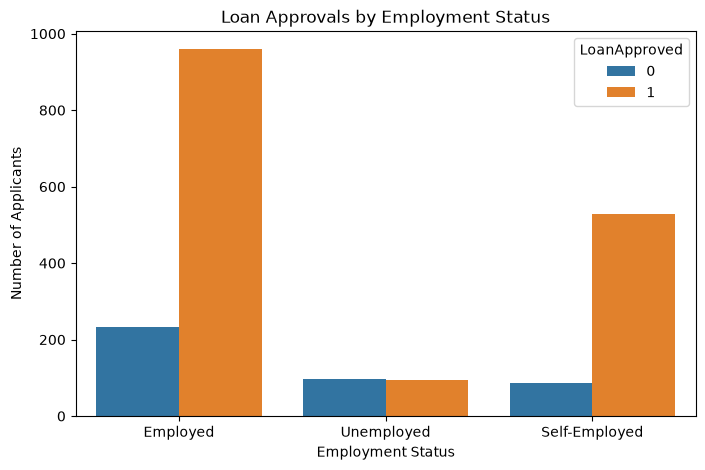

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="EmploymentStatus",
    hue="LoanApproved"
)

plt.title("Loan Approvals by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Number of Applicants")

plt.show()

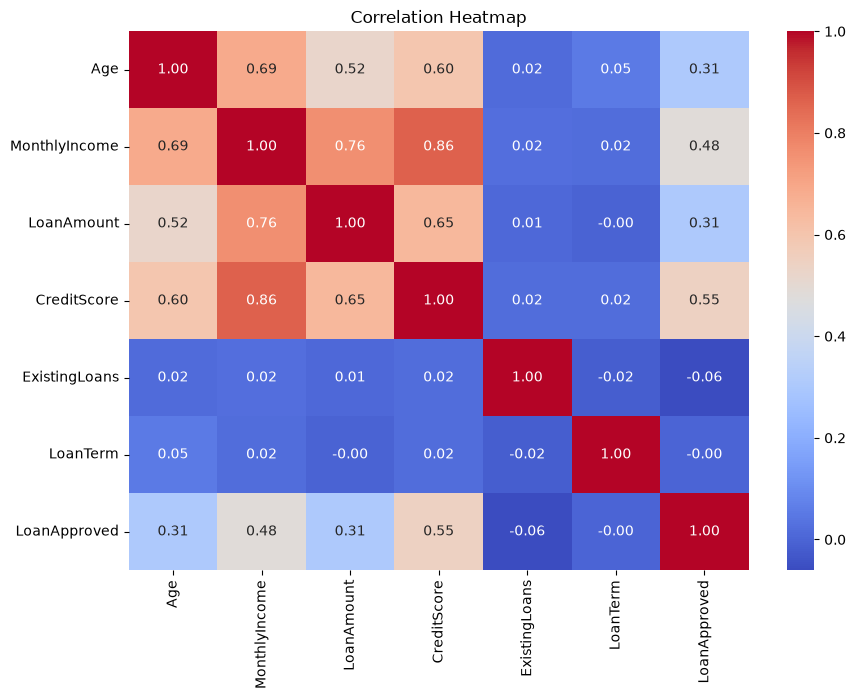

In [31]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

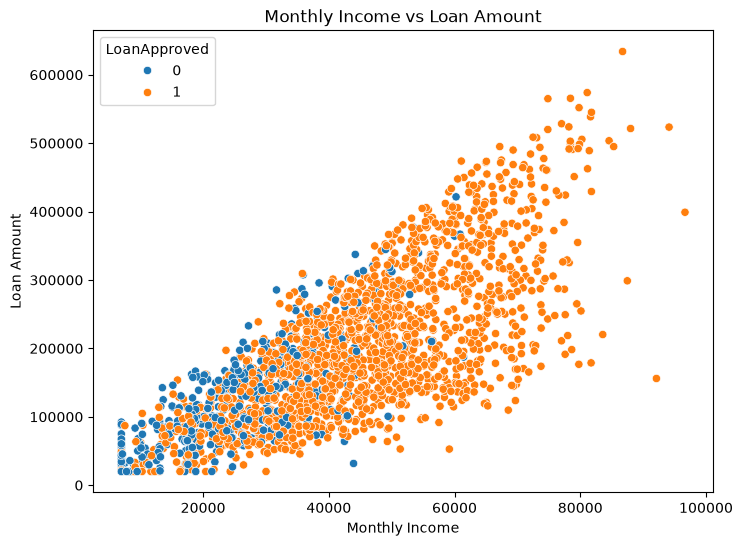

In [32]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="MonthlyIncome",
    y="LoanAmount",
    hue="LoanApproved"
)

plt.title(
    "Monthly Income vs Loan Amount"
)

plt.xlabel("Monthly Income")
plt.ylabel("Loan Amount")

plt.show()

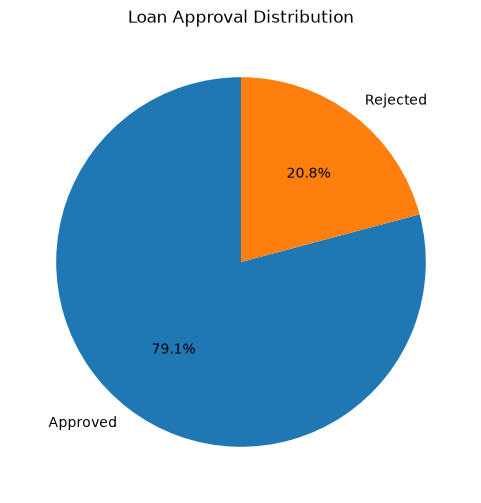

In [33]:
approval_counts = df[
    "LoanApproved"
].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    approval_counts,
    labels=["Approved", "Rejected"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Approval Distribution")

plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import pandas as pd
import numpy as np

df = pd.read_csv("loan_applications.csv")

print(df.head())
print(df.shape)

   ApplicantID  Gender   Age  MonthlyIncome  LoanAmount  CreditScore  \
0       100001    Male  32.0        18169.0    162004.0        569.0   
1       100002  Female  36.0        30000.0     78884.0        619.0   
2       100003    Male  44.0        26537.0    141011.0        582.0   
3       100004    Male  39.0        34601.0    228748.0        596.0   
4       100005    Male  28.0        10770.0     54137.0        551.0   

  EmploymentStatus  ExistingLoans  LoanTerm PropertyArea  LoanApproved  
0         Employed              0        36        Urban             0  
1         Employed              4        24   Semi-Urban             1  
2       Unemployed              0        60        Urban             0  
3    Self-Employed              1        24        Rural             0  
4         Employed              1        60   Semi-Urban             0  
(2000, 11)


In [37]:
X = df.drop(
    columns=["ApplicantID", "LoanApproved"]
)

y = df["LoanApproved"]

print("X shape:", X.shape)
print("y shape:", y.shape)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
numeric_features = [
    "Age",
    "MonthlyIncome",
    "LoanAmount",
    "CreditScore",
    "ExistingLoans",
    "LoanTerm"
]

print(numeric_features)
categorical_features = [
    "Gender",
    "EmploymentStatus",
    "PropertyArea"
]

print(categorical_features)

X shape: (2000, 9)
y shape: (2000,)
Training data: (1600, 9)
Testing data: (400, 9)
['Age', 'MonthlyIncome', 'LoanAmount', 'CreditScore', 'ExistingLoans', 'LoanTerm']
['Gender', 'EmploymentStatus', 'PropertyArea']


In [38]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])
classifier = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])
model.fit(X_train, y_train)

print("Model training completed successfully!")
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Model training completed successfully!
Predictions:
[1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [39]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        1          1
1        1          1
2        0          1
3        1          1
4        1          0
5        1          1
6        1          1
7        1          1
8        1          1
9        1          1
10       1          1
11       1          1
12       1          1
13       1          1
14       1          1
15       1          1
16       1          1
17       0          0
18       1          1
19       1          1


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Accuracy : 81.0 %
Precision: 0.9288
Recall   : 0.8233
F1 Score : 0.8729
Confusion Matrix:
[[ 63  20]
 [ 56 261]]


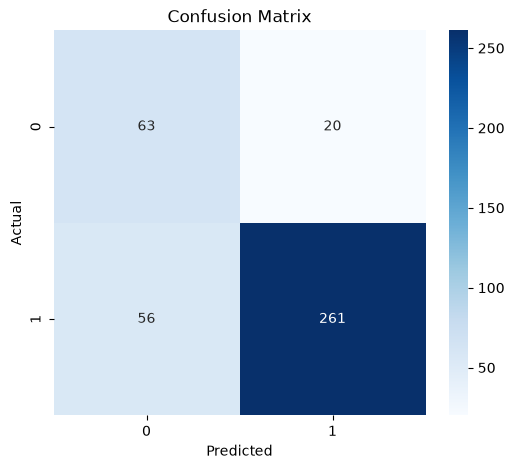

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [42]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy : 81.0 %
Precision: 0.9288
Recall   : 0.8233
F1 Score : 0.8729
[[ 63  20]
 [ 56 261]]


In [45]:
def predict_loan():
    print("===== Loan Approval Prediction =====")

    try:
        age = int(input("Enter Age: "))
        income = float(input("Enter Monthly Income: "))
        loan_amount = float(input("Enter Loan Amount: "))
        credit_score = int(input("Enter Credit Score: "))

        employment = input(
            "Enter Employment Status (Employed/Self-Employed/Unemployed): "
        )

        existing_loans = int(input("Enter Number of Existing Loans: "))
        loan_term = int(input("Enter Loan Term (12/24/36/48/60): "))

        property_area = input(
            "Enter Property Area (Urban/Semi-Urban/Rural): "
        )

        # Validate values
        if not 21 <= age <= 60:
            raise ValueError("Age must be between 21 and 60.")

        if income <= 0:
            raise ValueError("Monthly income must be greater than 0.")

        if loan_amount <= 0:
            raise ValueError("Loan amount must be greater than 0.")

        if not 300 <= credit_score <= 850:
            raise ValueError("Credit score must be between 300 and 850.")

        if employment not in ["Employed", "Self-Employed", "Unemployed"]:
            raise ValueError("Invalid employment status.")

        if existing_loans < 0:
            raise ValueError("Existing loans cannot be negative.")

        if loan_term not in [12, 24, 36, 48, 60]:
            raise ValueError("Loan term must be 12, 24, 36, 48 or 60.")

        if property_area not in ["Urban", "Semi-Urban", "Rural"]:
            raise ValueError("Invalid property area.")

        # Create input data
        new_applicant = pd.DataFrame({
            "Age": [age],
            "MonthlyIncome": [income],
            "LoanAmount": [loan_amount],
            "CreditScore": [credit_score],
            "EmploymentStatus": [employment],
            "ExistingLoans": [existing_loans],
            "LoanTerm": [loan_term],
            "PropertyArea": [property_area],
            "Gender": ["Male"]
        })

        # Make prediction
        prediction = model.predict(new_applicant)[0]

        print("\n===== Prediction Result =====")

        if prediction == 1:
            print("Loan Status: APPROVED")
        else:
            print("Loan Status: REJECTED")

    except ValueError as e:
        print("Invalid input:", e)
predict_loan()

===== Loan Approval Prediction =====


Enter Age:  30
Enter Monthly Income:  450000
Enter Loan Amount:  500000
Enter Credit Score:  450
Enter Employment Status (Employed/Self-Employed/Unemployed):  Employed
Enter Number of Existing Loans:  1
Enter Loan Term (12/24/36/48/60):  36
Enter Property Area (Urban/Semi-Urban/Rural):  Urban



===== Prediction Result =====
Loan Status: APPROVED


In [47]:
import joblib
joblib.dump(model, "loan_approval_model.pkl")

print("Model saved successfully!")
joblib.dump(model, "loan_approval_model.pkl")
loaded_model = joblib.load("loan_approval_model.pkl")
print("Model loaded successfully!")

Model saved successfully!
Model loaded successfully!


In [48]:
test_prediction = loaded_model.predict(X_test)

print("Prediction successful!")
print(test_prediction[:10])

Prediction successful!
[1 1 1 1 0 1 1 1 1 1]
